In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal,Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
# from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
import os
import pandas as pd
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

API_KEY = "USE_YOUR_API_KEY"

In [45]:
df = pd.read_csv('sales_kpi_df.csv')
df.head()

,revenue,customer_count,active_sellers,avg_spend_per_customer,gmv_per_active_seller
0,134.97,1,1,134.970000,134.970000
1,2443.57,19,16,128.608947,152.723125
2,1622.05,10,8,162.205000,202.756250
3,17515.56,108,69,162.181111,253.848696
4,10559.80,57,47,185.259649,224.676596


In [46]:
template1 = PromptTemplate(
    template="""
You are a Business Intelligence analyst performing KPI anomaly detection.

The following KPI lists are chronological time-series data. Position 1 represents Day 1, position 2 represents Day 2, and so on.

Revenue:
{revenue}

Customer Count:
{customer_count}

Active Sellers:
{active_sellers}

Average Spend per Customer:
{avg_spend_per_customer}

GMV per Active Seller:
{gmv_per_active_seller}

TASK:
Analyze each KPI independently and identify its single most significant anomalous period.

An anomaly may be:
- a sudden spike,
- a sudden drop,
- a sustained unusually high or low period,
- a clear trend change,
- an isolated value that strongly differs from nearby observations.

IMPORTANT RULES:

1. Return AT MOST ONE anomaly for each KPI.
2. There are 5 KPIs, so return at most 5 anomalies total.
3. Do not report normal day-to-day fluctuations.
4. Consecutive or nearby abnormal observations representing the same behavior MUST be grouped into ONE anomaly period.
5. Never create separate anomalies for consecutive days of the same KPI.
6. For each KPI, if multiple anomalous periods exist, return only the strongest one.
7. If a KPI has no meaningful anomaly, return nothing for that KPI.
8. Each KPI name may appear at most once in the output.

For a sustained anomaly:
- start_day = first day of abnormal behavior
- end_day = last day of the same abnormal behavior

Example:
If Revenue is unusually high from Day 45 through Day 52, return ONE anomaly with:
start_day = 45
end_day = 52

Do NOT return separate anomalies for Days 45, 46, 47, etc.

Allowed metric names:
- Revenue
- Customer Count
- Active Sellers
- Average Spend per Customer
- GMV per Active Seller

Allowed anomaly types:
- spike
- drop
- trend_change
- other

The description should briefly explain:
- what changed,
- the anomalous period,
- and how it differs from nearby observations.

Do not invent business causes or explanations that are not present in the KPI values.

Return only structured anomaly objects matching the required schema.
If no meaningful anomalies are found, return an empty anomalies list.
""",

    input_variables=[
        "revenue",
        "customer_count",
        "active_sellers",
        "avg_spend_per_customer",
        "gmv_per_active_seller"
    ]
)

In [47]:



class Anomaly(BaseModel):

    anomaly_id: str

    metric: Literal[
        "Revenue",
        "Customer Count",
        "Active Sellers",
        "Average Spend per Customer",
        "GMV per Active Seller"
    ]

    start_day: int | None
    end_day: int | None

    anomaly_type: Literal[
        "spike",
        "drop",
        "trend_change",
        "other"
    ]

    description: str


class AnomalyOutput(BaseModel):

    anomalies: list[Anomaly] = Field(
        default_factory=list,
        max_length=5,
        description="At most one strongest anomaly period per KPI"
    )

    # anomoly : list[str]



# class AnomalyOutput(BaseModel):
#     anomalies: list[schema_] = Field(
#         description="List of significant KPI anomalies"
#     )

    
class chat_state(TypedDict):

    sales_total : list[float]
    customer_count : list[float]
    active_sellers : list[float]
    avg_spend_per_customer : list[float]
    gmv_per_active_seller : list[float]
    anomalies : list[dict] 

# llm1 = HuggingFaceEndpoint(
#     repo_id="deepseek-ai/DeepSeek-R1",
#     task="text-generation",
#     huggingfacehub_api_token=API_KEY
# )

# llm1 = HuggingFaceEndpoint(
#     repo_id="google/gemma-2-9b-itXZ",
#     task="text-generation",
#     huggingfacehub_api_token=API_KEY
# )

# llm1 = HuggingFaceEndpoint(
#     repo_id="Qwen/Qwen2.5-7B-Instruct",
#     provider="featherless-ai",
#     task="conversational",
#     max_new_tokens=512,
#     huggingfacehub_api_token=API_KEY
# )

# model1 = ChatHuggingFace(llm=llm1)
# structured_model = model1.with_structured_output(schema_,method="json_schema")



model1 = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    google_api_key=API_KEY,
    temperature=0
)

structured_model = model1.with_structured_output(AnomalyOutput)

In [48]:
def base_node(state: chat_state):

    df = pd.read_csv("sales_kpi_df.csv")

    state["sales_total"] = df["revenue"].astype(float).tolist()
    state["customer_count"] = df["customer_count"].astype(float).tolist()
    state["active_sellers"] = df["active_sellers"].astype(float).tolist()
    state["avg_spend_per_customer"] = df["avg_spend_per_customer"].astype(float).tolist()
    state["gmv_per_active_seller"] = df["gmv_per_active_seller"].astype(float).tolist()

    return state


def anomoly_node(state: chat_state):

    prompt = template1.invoke({
        "revenue": state["sales_total"],
        "customer_count": state["customer_count"],
        "active_sellers": state["active_sellers"],
        "avg_spend_per_customer": state["avg_spend_per_customer"],
        "gmv_per_active_seller": state["gmv_per_active_seller"]
    })

    # answer = structured_model.invoke(prompt)
    answer = structured_model.invoke(prompt)

    state["anomalies"] = [a.model_dump() for a in answer.anomalies]

    return state


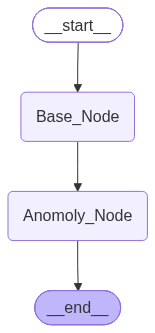

In [49]:
graph = StateGraph(chat_state)

graph.add_node("Base_Node", base_node)
graph.add_node("Anomoly_Node", anomoly_node)

graph.add_edge(START, "Base_Node")
graph.add_edge("Base_Node", "Anomoly_Node")
graph.add_edge("Anomoly_Node", END)

workflow = graph.compile()
workflow

In [50]:
initial_state = {

    "sales_total": [],
    "customer_count": [],
    "active_sellers": [],
    "avg_spend_per_customer": [],
    "gmv_per_active_seller": [],
    "anomalies": []

}

state = workflow.invoke(initial_state)


c:\Users\Santosh\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [52]:
print(state["anomalies"])

[{'anomaly_id': 'rev_anomaly_1', 'metric': 'Revenue', 'start_day': 300, 'end_day': 303, 'anomaly_type': 'spike', 'description': 'Revenue experiences an extreme spike between day 300 and 303, reaching a peak of 132,994.94 on day 301, significantly higher than surrounding baseline observations.'}, {'anomaly_id': 'cust_anomaly_1', 'metric': 'Customer Count', 'start_day': 300, 'end_day': 302, 'anomaly_type': 'spike', 'description': 'Customer count surges dramatically from day 300 to 302, reaching a peak of 990 on day 301, compared to typical baseline counts usually under 350.'}, {'anomaly_id': 'seller_anomaly_1', 'metric': 'Active Sellers', 'start_day': 300, 'end_day': 301, 'anomaly_type': 'spike', 'description': 'Active sellers sharply spike on days 300 and 301, peaking at 450 active sellers on day 301 before returning to normal levels.'}, {'anomaly_id': 'spend_anomaly_1', 'metric': 'Average Spend per Customer', 'start_day': 12, 'end_day': 14, 'anomaly_type': 'spike', 'description': 'Aver

### Agent 2